In [1]:
from sec_api import ExtractorApi # https://pypi.org/project/sec-api/
# get API from sec-api.io
extractorApi = ExtractorApi("ddd3179377838a6431a5cb7f37917469d26ef9f551355031171a3d69ac45b5d1")


# Tesla 10-K filing
filing_url = "https://www.sec.gov/Archives/edgar/data/320193/000032019323000106/aapl-20230930.htm"

# get the standardized and cleaned text of section 1A "Risk Factors"
section_text = extractorApi.get_section(filing_url, "1A", "text")

# get the original HTML of section 7 
# "Management’s Discussion and Analysis of Financial Condition and Results of Operations"
section_html = extractorApi.get_section(filing_url, "7", "html")

In [2]:
print (section_text)

 Item 1A. Risk Factors 

The Company&#8217;s business, reputation, results of operations, financial condition and stock price can be affected by a number of factors, whether currently known or unknown, including those described below. When any one or more of these risks materialize from time to time, the Company&#8217;s business, reputation, results of operations, financial condition and stock price can be materially and adversely affected. 

Because of the following factors, as well as other factors affecting the Company&#8217;s results of operations and financial condition, past financial performance should not be considered to be a reliable indicator of future performance, and investors should not use historical trends to anticipate results or trends in future periods. This discussion of risk factors contains forward-looking statements. 

This section should be read in conjunction with Part II, Item 7, &#8220;Management&#8217;s Discussion and Analysis of Financial Condition and Resu

# List of 10-K items:
1 - Business\
1A - Risk Factors\
1B - Unresolved Staff Comments\
2 - Properties\
3 - Legal Proceedings\
4 - Mine Safety Disclosures\
5 - Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities\
6 - Selected Financial Data (prior to February 2021)\
7 - Management’s Discussion and Analysis of Financial Condition and Results of Operations\
7A - Quantitative and Qualitative Disclosures about Market Risk\
8 - Financial Statements and Supplementary Data\
9 - Changes in and Disagreements with Accountants on Accounting and Financial Disclosure\
9A - Controls and Procedures\
9B - Other Information\
10 - Directors, Executive Officers and Corporate Governance\
11 - Executive Compensation\
12 - Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters\
13 - Certain Relationships and Related Transactions, and Director Independence\
14 - Principal Accountant Fees and Services\

# List of 8-K items:
1.01: Entry into a Material Definitive Agreement\
1.02: Termination of a Material Definitive Agreement\
1.03: Bankruptcy or Receivership\
1.04: Mine Safety - Reporting of Shutdowns and Patterns of Violations\
2.01: Completion of Acquisition or Disposition of Assets\
2.02: Results of Operations and Financial Condition\
2.03: Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement of a Registrant\
2.04: Triggering Events That Accelerate or Increase a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement\
2.05: Cost Associated with Exit or Disposal Activities\
2.06: Material Impairments\
3.01: Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing\
3.02: Unregistered Sales of Equity Securities\
3.03: Material Modifications to Rights of Security Holders\
4.01: Changes in Registrant's Certifying Accountant\
4.02: Non-Reliance on Previously Issued Financial Statements or a Related Audit Report or Completed Interim Review\
5.01: Changes in Control of Registrant\
5.02: Departure of Directors or Certain Officers; Election of Directors; Appointment of Certain Officers: Compensatory Arrangements of Certain Officers\
5.03: Amendments to Articles of Incorporation or Bylaws; Change in Fiscal Year\
5.04: Temporary Suspension of Trading Under Registrant's Employee Benefit Plans\
5.05: Amendments to the Registrant's Code of Ethics, or Waiver of a Provision of the Code of Ethics\
5.06: Change in Shell Company Status\
5.07: Submission of Matters to a Vote of Security Holders\
5.08: Shareholder Nominations Pursuant to Exchange Act Rule 14a-11\
6.01: ABS Informational and Computational Material\
6.02: Change of Servicer or Trustee\
6.03: Change in Credit Enhancement or Other External Support\
6.04: Failure to Make a Required Distribution\
6.04: Failure to Make a Required Distribution\
6.04: Failure to Make a Required Distribution\
6.05: Securities Act Updating Disclosure\
6.06: Static Pool\
6.10: Alternative Filings of Asset-Backed Issuers\
7.01: Regulation FD Disclosure\
8.01: Other Events\
9.01: Financial Statements and Exhibits\

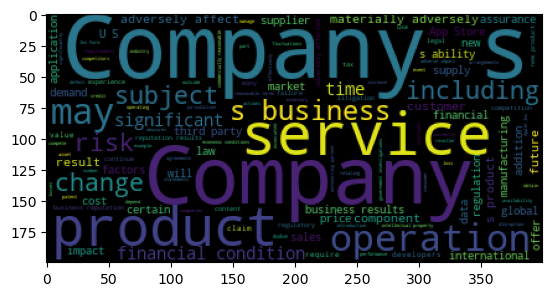

In [3]:
import pandas as pd
import numpy as np

#for plotting images & adjusting colors
import matplotlib.pyplot as plt
import matplotlib as mpl
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image

wc = WordCloud().generate(section_text)
plt.imshow(wc)


In [5]:
# import libraries
import pandas as pd

import nltk

from nltk.sentiment.vader import SentimentIntensityAnalyzer

from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize

from nltk.stem import WordNetLemmatizer

# if you don't have vadar_lexicon data, you can run the following command in a terminal window:
#python -m nltk.downloader vader_lexicon

# download nltk corpus (first time only)
#import nltk

#nltk.download('all')

In [6]:
#Create a Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

In [8]:
#Analyze section_text
scores = analyzer.polarity_scores(section_text)

print(scores)
#the compound key is a normalized score that ranges from -1(most negative) to 1(most positive)

{'neg': 0.094, 'neu': 0.818, 'pos': 0.087, 'compound': -0.9938}


In [9]:
#We can also check which score is the highest and use that to classify the text as positive, negative, or neutral.
if scores['compound'] >= 0.5:
    print("Positive")
elif scores['compound'] >-0.5:
    print("Neutral")
else:
    print("Negative")

Negative
